In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from scipy.stats import levene
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print

In [82]:
ab_users = pd.read_excel('C:/Users/user/Тестовое_Т_образование/dannye-dlia-keisa-po-pa-cebbefc3-5b29-4f88-b6d4-3336c88d743f.xlsx')
ab_payment = pd.read_excel('C:/Users/user/Тестовое_Т_образование/dannye-dlia-keisa-po-pa-cebbefc3-5b29-4f88-b6d4-3336c88d743f.xlsx',
                           sheet_name='Платежи')

### Проверка на пропуски и дубликаты (очистка данных)

In [83]:
def info(df):
    display(df.head(3))
    print(f"\nКол-во строк и колонок: {df.shape}")
    print("\n", df.dtypes)
    print("\nПропуски:")
    print(df.isna().sum())
    print(f"\nДубликаты: {df.duplicated().sum()}")



In [84]:
info(ab_users)

,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android



Кол-во строк и колонок: (1504, 5)

 user_id         int64
group          object
age             int64
city           object
device_type    object
dtype: object

Пропуски:
user_id        0
group          1
age            0
city           1
device_type    0
dtype: int64

Дубликаты: 0


In [85]:
print(ab_users[ab_users['city'].isna()])

      user_id group  age city device_type
1503     9004     A   30  NaN     android


In [86]:
print(ab_users[ab_users['group'].isna()])

      user_id group  age    city device_type
1500     9001   NaN   25  Москва         ios


In [87]:
ab_users.age.describe()

count    1504.000000
mean       32.745346
std         8.410915
min        -5.000000
25%        27.000000
50%        33.000000
75%        38.000000
max       150.000000
Name: age, dtype: float64

In [88]:
# Пользователи с возрастом -5 и 150
print("Пользователь с возрастом -5:")
print(ab_users[ab_users['age'] == -5])

print("\nПользователь с возрастом 150:")
print(ab_users[ab_users['age'] == 150])

Пользователь с возрастом -5:
      user_id group  age city device_type
1501     9002     A   -5  СПб     android

Пользователь с возрастом 150:
      user_id group  age    city device_type
1502     9003     B  150  Регион         ios


In [5]:
ab_users = ab_users[ab_users['group'].notna()]

In [6]:
ab_users.group.value_counts()

group
A    752
B    751
Name: count, dtype: int64

In [7]:
info(ab_payment)

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT



Кол-во строк и колонок: (2661, 7)

 payment_id                  int64
user_id                   float64
group                      object
step1_opened       datetime64[ns]
step2_entered      datetime64[ns]
step3_confirmed    datetime64[ns]
step4_success      datetime64[ns]
dtype: object

Пропуски:
payment_id            0
user_id               1
group                 0
step1_opened          0
step2_entered       405
step3_confirmed     942
step4_success      1139
dtype: int64

Дубликаты: 0


In [89]:
print("Пользователь 9002 в ab_payment:")
print(ab_payment[ab_payment['user_id'] == 9002])

print("\nПользователь 9003 в ab_payment:")
print(ab_payment[ab_payment['user_id'] == 9003])

Пользователь 9002 в ab_payment:
Empty DataFrame
Columns: [payment_id, user_id, group, step1_opened, step2_entered, step3_confirmed, step4_success]
Index: []

Пользователь 9003 в ab_payment:
Empty DataFrame
Columns: [payment_id, user_id, group, step1_opened, step2_entered, step3_confirmed, step4_success]
Index: []


In [91]:
users_without_payments = ab_users[~ab_users['user_id'].isin(ab_payment['user_id'])]

print(f"Всего пользователей в ab_users: {len(ab_users)}")
print(f"Пользователей без платежей: {len(users_without_payments)}")
print(f"Доля без платежей: {len(users_without_payments) / len(ab_users):.2%}")

print("\nРаспределение по группам среди пользователей без платежей:")
print(users_without_payments['group'].value_counts())

print("\nРаспределение по группам среди всех пользователей ab_users:")
print(ab_users['group'].value_counts())

Всего пользователей в ab_users: 1504
Пользователей без платежей: 3
Доля без платежей: 0.20%

Распределение по группам среди пользователей без платежей:
group
A    1
B    1
Name: count, dtype: int64

Распределение по группам среди всех пользователей ab_users:
group
A    752
B    751
Name: count, dtype: int64


In [8]:
ab_payment = ab_payment[ab_payment['user_id'].notna()]

In [9]:
ab_payment.step1_opened.min()

Timestamp('2024-04-01 00:19:00')

In [10]:
ab_payment.step1_opened.max()

Timestamp('2024-04-30 23:17:00')

In [11]:
ab_payment['user_id'] = ab_payment['user_id'].astype(int)

### Объединение таблиц

In [12]:
ab_payment['step1'] = ab_payment['step1_opened'].apply(lambda x: 1 if pd.notna(x) else 0)
ab_payment['step2'] = ab_payment['step2_entered'].apply(lambda x: 1 if pd.notna(x) else 0)
ab_payment['step3'] = ab_payment['step3_confirmed'].apply(lambda x: 1 if pd.notna(x) else 0)
ab_payment['step4'] = ab_payment['step4_success'].apply(lambda x: 1 if pd.notna(x) else 0)

In [13]:
print(f"Количество строк ab_payment: {ab_payment.shape}")
print(f"Количество строк ab_users: {ab_users.shape}")

Количество строк ab_payment: (2660, 11)
Количество строк ab_users: (1503, 5)


In [14]:
ab_all = pd.merge(ab_payment, ab_users, on='user_id', how='left')

In [15]:
ab_all.head()

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,step1,step2,step3,step4,group_y,age,city,device_type
0,5001,1001,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT,1,1,0,0,A,31,Москва,ios
1,5002,1002,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT,1,1,0,0,A,31,Москва,ios
2,5003,1003,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT,1,1,0,0,A,25,Москва,android
3,5004,1004,A,2024-04-09 16:02:00,NaT,NaT,NaT,1,0,0,0,A,20,Москва,ios
4,5005,1004,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00,1,1,1,1,A,20,Москва,ios


In [16]:
print((ab_all['group_x'] == ab_all['group_y']).all())

False


In [17]:
mismatch = ab_all[ab_all['group_x'] != ab_all['group_y']]
print(f"Количество несовпадений: {len(mismatch)}")

Количество несовпадений: 1


In [18]:
print("Пропуски в group_x (из ab_payment):", ab_all['group_x'].isna().sum())
print("Пропуски в group_y (из ab_users):", ab_all['group_y'].isna().sum())

Пропуски в group_x (из ab_payment): 0
Пропуски в group_y (из ab_users): 0


In [19]:
display(mismatch)

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,step1,step2,step3,step4,group_y,age,city,device_type
2659,99002,1010,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,1,1,1,1,A,26,Москва,android


In [20]:
user_1010 = ab_all[ab_all['user_id'] == 1010]

In [21]:
user_1010

,payment_id,user_id,group_x,step1_opened,step2_entered,step3_confirmed,step4_success,step1,step2,step3,step4,group_y,age,city,device_type
14,5015,1010,A,2024-04-27 13:26:00,NaT,NaT,NaT,1,0,0,0,A,26,Москва,android
2659,99002,1010,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,1,1,1,1,A,26,Москва,android


In [22]:
ab_all['group'] = ab_all['group_y']
ab_all = ab_all.drop(columns=['group_x', 'group_y'])

### Проверка валидности групп

In [23]:
def groups_check(df):
    print("\nРаспределение по группам:")
    print(df['group'].value_counts())
    
    print("\nТип устройства:")
    print(df.groupby('group')['device_type'].value_counts())
    
    print("\nГорода:")
    print(df.groupby('group')['city'].value_counts().head(5))
    
    print("\nВозраст:")
    print(df.groupby('group')['age'].describe())
    
    print("\nКонверсия по группам:")
    print(df.groupby('group')['step4'].mean())
    
groups_check(ab_all)


Распределение по группам:
group
B    1351
A    1309
Name: count, dtype: int64

Тип устройства:
group  device_type
A      android        715
       ios            594
B      ios            685
       android        666
Name: count, dtype: int64

Города:
group  city  
A      Москва    503
       Регион    461
       СПб       344
B      Москва    567
       Регион    428
Name: count, dtype: int64

Возраст:
        count       mean       std   min   25%   50%   75%   max
group                                                           
A      1309.0  32.750955  7.812834  20.0  27.0  32.0  38.0  60.0
B      1351.0  32.788305  7.736563  20.0  27.0  33.0  39.0  60.0

Конверсия по группам:
group
A    0.498090
B    0.643967
Name: step4, dtype: float64

Воронка:
Шаг с 1 по 2: 84.8%
Шаг с 2 по 3: 76.2%
Шаг с 3 по 4: 88.5%
Шаг с 1 по 4: 57.2%


In [24]:
print("\nВремя между шагами (в минутах):")
for group in ['A', 'B']:
    data = ab_all[ab_all['group'] == group]
    print(f"\nГруппа {group}:")
    print("\nШаг с 1 по 4:")
    print(((data['step4_success'] - data['step1_opened']).dt.total_seconds().dropna() / 60).describe())


Время между шагами (в минутах):

Группа A:

Шаг с 1 по 4:
count    652.000000
mean      12.414110
std        2.674391
min        6.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       23.000000
dtype: float64

Группа B:

Шаг с 1 по 4:
count    870.000000
mean      12.354023
std        2.907267
min        5.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       24.000000
dtype: float64


In [25]:
# Анализ количества платежей на пользователя
payments_per_user = ab_all.groupby('user_id')['payment_id'].count()
print("\nКоличество платежей на пользователя:")
print(payments_per_user.describe())


Количество платежей на пользователя:
count    1501.000000
mean        1.772152
std         0.901878
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: payment_id, dtype: float64


In [26]:
# Проверяем пользователей с 4 платежами - нет ли там ошибок?
users_4 = payments_per_user[payments_per_user == 4].index
print(f"Пользователей с 4 платежами: {len(users_4)}")
display(ab_all[ab_all['user_id'].isin(users_4)][['user_id', 'payment_id', 'step1_opened', 'step4_success']].head(10))

Пользователей с 4 платежами: 80


,user_id,payment_id,step1_opened,step4_success
62,1036,5063,2024-04-09 00:21:00,NaT
63,1036,5064,2024-04-19 19:24:00,2024-04-19 19:38:00
64,1036,5065,2024-04-08 11:28:00,NaT
65,1036,5066,2024-04-25 06:58:00,NaT
78,1045,5079,2024-04-13 02:21:00,NaT
79,1045,5080,2024-04-18 22:15:00,2024-04-18 22:28:00
80,1045,5081,2024-04-15 10:35:00,2024-04-15 10:55:00
81,1045,5082,2024-04-16 20:42:00,NaT
188,1109,5189,2024-04-16 21:06:00,NaT
189,1109,5190,2024-04-06 02:23:00,NaT


In [79]:
# Проверка по возрасту
stat, p = levene(
    ab_all[ab_all['group'] == 'A']['age'].dropna(),
    ab_all[ab_all['group'] == 'B']['age'].dropna(),
)

print("Возраст: проверка однородности дисперсий и нормальности")
print(f"\nОднородность: F = {stat:.4f}, p = {p:.4f}")
print("\nПроверка нормальности")
display(pg.normality(data=ab_all, dv='age', group='group'))

print("\nТак как данные распределены ненормально, применяем тест Манна-Уитни")

age_A = ab_all[ab_all['group'] == 'A']['age'].dropna()
age_B = ab_all[ab_all['group'] == 'B']['age'].dropna()
display(pg.mwu(x=age_A, y=age_B))

print("\nВывод: различий в группах по возрасту нет")

Возраст: проверка однородности дисперсий и нормальности

Однородность: F = 0.1636, p = 0.6859

Проверка нормальности


,W,pval,normal
group,,,
A,0.977503,2.023288e-13,False
B,0.974995,1.480798e-14,False



Так как данные распределены ненормально, применяем тест Манна-Уитни


,U_val,alternative,p_val,RBC,CLES
MWU,867329.5,two-sided,0.393064,-0.019113,0.490444



Вывод: различий в группах по возрасту нет


In [38]:
# Тип устройства (device_type)
print("Тип устройства")
table_device = pd.crosstab(ab_all['group'], ab_all['device_type'])
print(table_device)
print("\nХи-квадрат тест:")
chi2, p, dof, expected = stats.chi2_contingency(table_device)
print(f"χ² = {chi2:.4f}, p = {p:.4f}")

print("\nГруппы различаются по типам устройств")

Тип устройства
device_type  android  ios
group                    
A                715  594
B                666  685

Хи-квадрат тест:
χ² = 7.3401, p = 0.0067

Группы различаются по типам устройств


In [40]:
# Сохраняется ли эффект внутри каждой подгруппы
for device in ['android', 'ios']:
    print(f"\n{device}")
    data = ab_all[ab_all['device_type'] == device]
    conv_A = data[data['group'] == 'A']['step4'].mean()
    conv_B = data[data['group'] == 'B']['step4'].mean()
    print(f"Группа A: {conv_A:.2%}")
    print(f"Группа B: {conv_B:.2%}")
    print(f"Разница: {(conv_B - conv_A):.2%}")


android
Группа A: 48.95%
Группа B: 63.81%
Разница: 14.86%

ios
Группа A: 50.84%
Группа B: 64.96%
Разница: 14.12%


In [39]:
# 2. Город (city)
print("Город")

table_city = pd.crosstab(ab_all['group'], ab_all['city'])
print(table_city)
print("\nХи-квадрат тест:")
chi2, p, dof, expected = stats.chi2_contingency(table_city)
print(f"χ² = {chi2:.4f}, p = {p:.4f}")

print("\nРаспределение по городам не отличается между группами")


Город
city   Москва  Регион  СПб
group                     
A         503     461  344
B         567     428  356

Хи-квадрат тест:
χ² = 4.5645, p = 0.1021

Распределение по городам не отличается между группами


### Проверка к стат. тесту

Воронка по группам (сравнение)

Группа A:
  Всего платежей: 1309
  Шаг 1→2: 81.1%
  Шаг 2→3: 71.5%
  Шаг 3→4: 85.9%
  Шаг 1→4: 49.8%

Группа B:
  Всего платежей: 1351
  Шаг 1→2: 88.4%
  Шаг 2→3: 80.4%
  Шаг 3→4: 90.6%
  Шаг 1→4: 64.4%
Разницу между группами
Шаг 1→2: A=81.1%, B=88.4%, разница=7.2%
Шаг 2→3: A=71.5%, B=80.4%, разница=8.9%
Шаг 3→4: A=85.9%, B=90.6%, разница=4.7%
Шаг 1→4: A=49.8%, B=64.4%, разница=14.6%


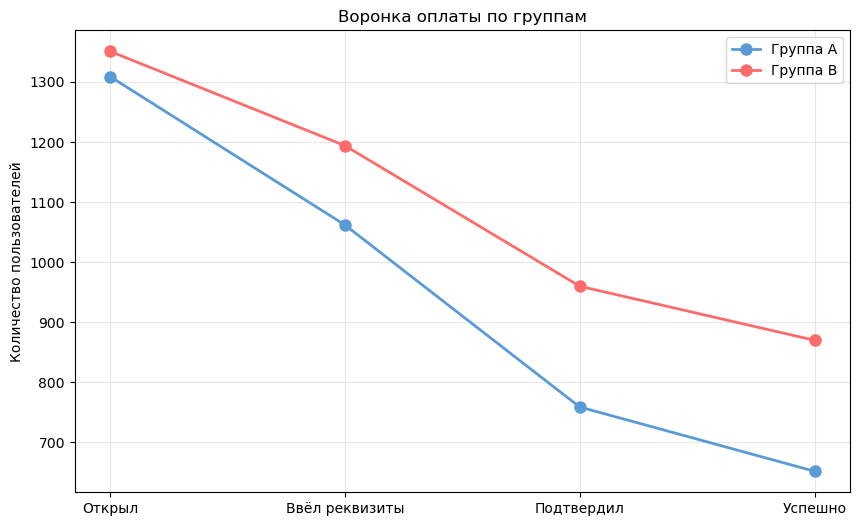

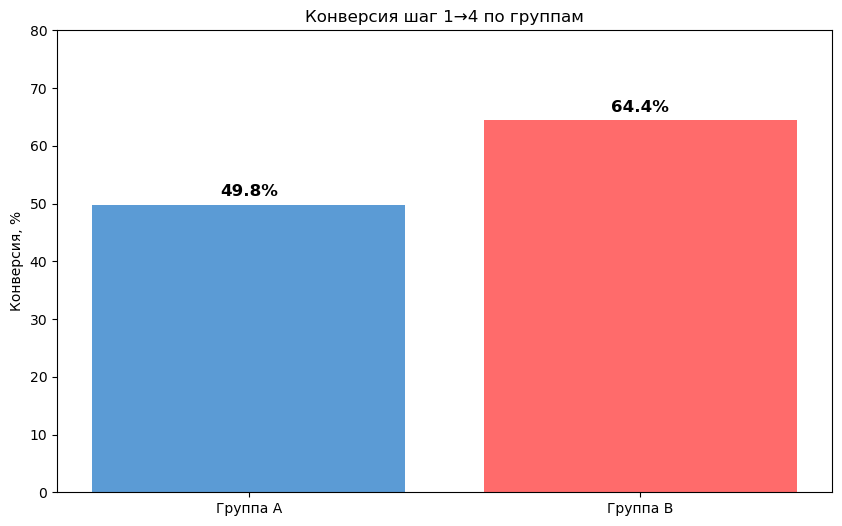

In [69]:

print("Воронка по группам (сравнение)")

for group in ['A', 'B']:
    data = ab_all[ab_all['group'] == group]
    print(f"\nГруппа {group}:")
    print(f"  Всего платежей: {len(data)}")
    print(f"  Шаг 1→2: {data['step2'].sum()/data['step1'].sum():.1%}")
    print(f"  Шаг 2→3: {data['step3'].sum()/data['step2'].sum():.1%}")
    print(f"  Шаг 3→4: {data['step4'].sum()/data['step3'].sum():.1%}")
    print(f"  Шаг 1→4: {data['step4'].sum()/data['step1'].sum():.1%}")

print("Разницу между группами")

conv_1_2_A = ab_all[ab_all['group'] == 'A']['step2'].sum() / ab_all[ab_all['group'] == 'A']['step1'].sum()
conv_1_2_B = ab_all[ab_all['group'] == 'B']['step2'].sum() / ab_all[ab_all['group'] == 'B']['step1'].sum()

conv_2_3_A = ab_all[ab_all['group'] == 'A']['step3'].sum() / ab_all[ab_all['group'] == 'A']['step2'].sum()
conv_2_3_B = ab_all[ab_all['group'] == 'B']['step3'].sum() / ab_all[ab_all['group'] == 'B']['step2'].sum()

conv_3_4_A = ab_all[ab_all['group'] == 'A']['step4'].sum() / ab_all[ab_all['group'] == 'A']['step3'].sum()
conv_3_4_B = ab_all[ab_all['group'] == 'B']['step4'].sum() / ab_all[ab_all['group'] == 'B']['step3'].sum()

conv_1_4_A = ab_all[ab_all['group'] == 'A']['step4'].sum() / ab_all[ab_all['group'] == 'A']['step1'].sum()
conv_1_4_B = ab_all[ab_all['group'] == 'B']['step4'].sum() / ab_all[ab_all['group'] == 'B']['step1'].sum()

print(f"Шаг 1→2: A={conv_1_2_A:.1%}, B={conv_1_2_B:.1%}, разница={(conv_1_2_B-conv_1_2_A):.1%}")
print(f"Шаг 2→3: A={conv_2_3_A:.1%}, B={conv_2_3_B:.1%}, разница={(conv_2_3_B-conv_2_3_A):.1%}")
print(f"Шаг 3→4: A={conv_3_4_A:.1%}, B={conv_3_4_B:.1%}, разница={(conv_3_4_B-conv_3_4_A):.1%}")
print(f"Шаг 1→4: A={conv_1_4_A:.1%}, B={conv_1_4_B:.1%}, разница={(conv_1_4_B-conv_1_4_A):.1%}")

steps = ['Открыл', 'Ввёл реквизиты', 'Подтвердил', 'Успешно']
funnel_A = [
    ab_all[ab_all['group'] == 'A']['step1'].sum(),
    ab_all[ab_all['group'] == 'A']['step2'].sum(),
    ab_all[ab_all['group'] == 'A']['step3'].sum(),
    ab_all[ab_all['group'] == 'A']['step4'].sum()
]
funnel_B = [
    ab_all[ab_all['group'] == 'B']['step1'].sum(),
    ab_all[ab_all['group'] == 'B']['step2'].sum(),
    ab_all[ab_all['group'] == 'B']['step3'].sum(),
    ab_all[ab_all['group'] == 'B']['step4'].sum()
]

plt.figure(figsize=(10, 6))
plt.plot(steps, funnel_A, marker='o', label='Группа A', linewidth=2, markersize=8, color='#5B9BD5')
plt.plot(steps, funnel_B, marker='o', label='Группа B', linewidth=2, markersize=8, color='#FF6B6B')
plt.ylabel('Количество пользователей')
plt.title('Воронка оплаты по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

groups = ['Группа А', 'Группа B']
conversions = [
    ab_all[ab_all['group'] == 'A']['step4'].mean() * 100,
    ab_all[ab_all['group'] == 'B']['step4'].mean() * 100
]

plt.figure(figsize=(10, 6))
bars = plt.bar(groups, conversions, color=['#5B9BD5', '#FF6B6B'])
plt.ylabel('Конверсия, %')
plt.title('Конверсия шаг 1→4 по группам')
plt.ylim(0, 80)

# Подписи значений на столбцах
for bar, val in zip(bars, conversions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

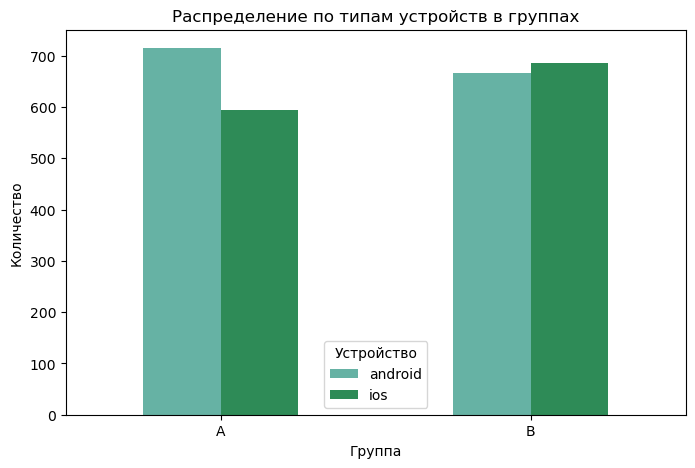

In [77]:
device_crosstab = pd.crosstab(ab_all['group'], ab_all['device_type'])
device_crosstab.plot(kind='bar', figsize=(8, 5), color=['#66B2A4', '#2E8B57'])
plt.title('Распределение по типам устройств в группах')
plt.ylabel('Количество')
plt.xlabel('Группа')
plt.legend(title='Устройство')
plt.xticks(rotation=0)
plt.show()

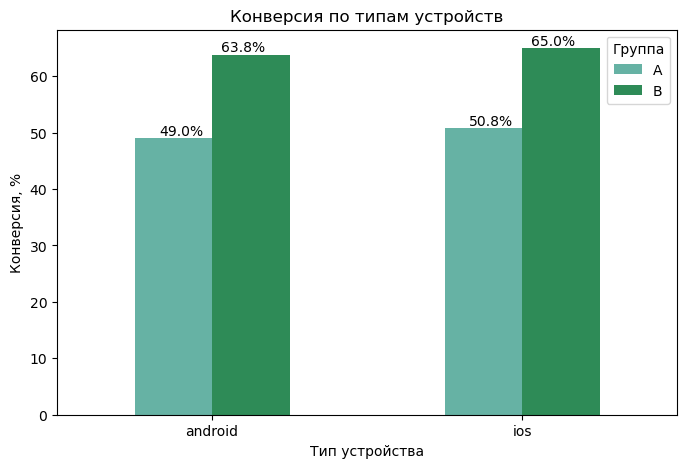

In [72]:
# Данные для графика: конверсия по группе и устройству
conv_by_device = ab_all.groupby(['device_type', 'group'])['step4'].mean().unstack() * 100

# Построение
conv_by_device.plot(kind='bar', figsize=(8, 5), color=['#66B2A4', '#2E8B57'])
plt.title('Конверсия по типам устройств')
plt.ylabel('Конверсия, %')
plt.xlabel('Тип устройства')
plt.legend(title='Группа')
plt.xticks(rotation=0)
for i, row in enumerate(conv_by_device.values):
    for j, val in enumerate(row):
        plt.text(i + j*0.2 - 0.1, val + 0.5, f'{val:.1f}%', ha='center')
plt.show()

### Стат. тесты

In [56]:
conv_A = ab_all[ab_all['group'] == 'A']['step4'].sum()
conv_B = ab_all[ab_all['group'] == 'B']['step4'].sum()
total_A = len(ab_all[ab_all['group'] == 'A'])
total_B = len(ab_all[ab_all['group'] == 'B'])

print(f"\nГруппа A: {conv_A} успешных из {total_A} ({conv_A/total_A:.2%})")
print(f"Группа B: {conv_B} успешных из {total_B} ({conv_B/total_B:.2%})")
print(f"Разница: {(conv_B/total_B - conv_A/total_A):.2%}")

count = [conv_A, conv_B]
nobs = [total_A, total_B]
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"\nZ-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")



Группа A: 652 успешных из 1309 (49.81%)
Группа B: 870 успешных из 1351 (64.40%)
Разница: 14.59%

Z-статистика: -7.6023
p-value: 0.000000


In [51]:
# Хи-квадрат тест через pingouin
table = pd.crosstab(ab_all['group'], ab_all['step4'])
result = pg.chi2_independence(data=ab_all, x='group', y='step4')
display(result)

(step4           0           1
 group                        
 A      560.015789  748.984211
 B      577.984211  773.015789,
 step4      0      1
 group              
 A      656.5  652.5
 B      481.5  869.5,
                  test    lambda       chi2  dof          pval    cramer  power
 0             pearson  1.000000  57.201247  1.0  3.934217e-14  0.146643    1.0
 1        cressie-read  0.666667  57.242347  1.0  3.852854e-14  0.146696    1.0
 2      log-likelihood  0.000000  57.399722  1.0  3.556576e-14  0.146897    1.0
 3       freeman-tukey -0.500000  57.584161  1.0  3.238227e-14  0.147133    1.0
 4  mod-log-likelihood -1.000000  57.826287  1.0  2.863177e-14  0.147442    1.0
 5              neyman -2.000000  58.487169  1.0  2.046211e-14  0.148282    1.0)

In [54]:

print("Проверка каждого шага")

steps = [
    ('с 1 по 2', 'step1', 'step2'),
    ('с 2 по 3', 'step2', 'step3'),
    ('с 3 по 4', 'step3', 'step4')
]

for step_name, from_step, to_step in steps:
    count_A = ab_all[(ab_all['group'] == 'A') & (ab_all[to_step] == 1)].shape[0]
    count_B = ab_all[(ab_all['group'] == 'B') & (ab_all[to_step] == 1)].shape[0]
    total_A = ab_all[(ab_all['group'] == 'A') & (ab_all[from_step] == 1)].shape[0]
    total_B = ab_all[(ab_all['group'] == 'B') & (ab_all[from_step] == 1)].shape[0]
    
    if total_A > 0 and total_B > 0:
        z_stat, p_value = proportions_ztest(
            [count_A, count_B], 
            [total_A, total_B], 
            alternative='two-sided'
        )
        print(f"\nШаг {step_name}:")
        print(f"  A: {count_A}/{total_A} = {count_A/total_A:.1%}")
        print(f"  B: {count_B}/{total_B} = {count_B/total_B:.1%}")
        print(f"  Разница: {(count_B/total_B - count_A/total_A):.1%}")
        print(f"  p-value: {p_value:.6f}")

Проверка каждого шага

Шаг с 1 по 2:
  A: 1062/1309 = 81.1%
  B: 1194/1351 = 88.4%
  Разница: 7.2%
  p-value: 0.000000

Шаг с 2 по 3:
  A: 759/1062 = 71.5%
  B: 960/1194 = 80.4%
  Разница: 8.9%
  p-value: 0.000001

Шаг с 3 по 4:
  A: 652/759 = 85.9%
  B: 870/960 = 90.6%
  Разница: 4.7%
  p-value: 0.002271


In [80]:
def bootstrap_ci_correct(data, group_col, value_col, n_bootstrap=10000, ci=95):
    diff = []
    group_A = data[data[group_col] == 'A']
    group_B = data[data[group_col] == 'B']
    
    for _ in range(n_bootstrap):
        sample_A = group_A.sample(n=len(group_A), replace=True)
        sample_B = group_B.sample(n=len(group_B), replace=True)
        conv_A = sample_A[value_col].mean()
        conv_B = sample_B[value_col].mean()
        diff.append(conv_B - conv_A)
    
    lower = np.percentile(diff, (100 - ci) / 2)
    upper = np.percentile(diff, 100 - (100 - ci) / 2)
    return lower, upper, np.mean(diff)

lower, upper, mean_diff = bootstrap_ci_correct(ab_all, 'group', 'step4')
print(f"Средняя разница: {mean_diff:.2%}")
print(f"95% ДИ: [{lower:.2%}, {upper:.2%}]")

Средняя разница: 14.61%
95% ДИ: [10.90%, 18.30%]


# Результаты A/B теста новой формы оплаты ЖКХ

## Проверка баланса групп

| Признак | Метод проверки | p-value | Вывод |
|---------|---------------|---------|-------|
| Возраст | Тест Крускала-Уоллиса | 0.393 |  Сбалансированы |
| Город | Хи-квадрат тест | 0.102 |  Сбалансированы |
| Тип устройства | Хи-квадрат тест | 0.0067 |  Есть смещение |

## Ключевые метрики

| Метрика | Группа A (контроль) | Группа B (новая форма) | Разница |
|---------|-------------------|----------------------|---------|
| **Конверсия 1→4** | **49.8%** | **64.4%** | **+14.6 п.п.** |
| Шаг 1→2 | 81.1% | 88.4% | +7.2 п.п. |
| Шаг 2→3 | 71.5% | 80.4% | +8.9 п.п. |
| Шаг 3→4 | 85.9% | 90.6% | +4.7 п.п. |

## Статистическая значимость

**Метод:** Z-тест для пропорций

| Шаг | p-value |
|-----|---------|
| Шаг 1→2 | 0.000000 |
| Шаг 2→3 | 0.000001 |
| Шаг 3→4 | 0.002271 |
| **Шаг 1→4** | **0.000000** |

**Дополнительно:**
- Хи-квадрат тест (p = 3.93e-14)
- Bootstrap 95% ДИ для разницы конверсий: [10.84%, 18.37%]

## Выводы

1. **Новая форма статистически значимо улучшает общую конверсию** (p < 0.001)
2. Улучшение наблюдается на всех этапах воронки с высокой статистической значимостью
3. Группы сбалансированы по возрасту и городу. Небольшое смещение по типу устройства не влияет на результат, так как эффект сохраняется внутри каждой подгруппы (Android: +14.86%, iOS: +14.12%)

## Рекомендация

**Запускать новую форму на всех пользователей**